# 04 — Opportunity Value Modeling

Goal: understand what characteristics are associated with high-value opportunities, and
whether apparent product/segment/geography effects hold up once we control for the others
at the same time (this is where the "is Product X valuable, or is it just sold mostly to
Enterprise?" question from the project brief actually gets answered).

Target: `opportunity_value` (opportunity-level grain, 145 rows).
Predictors: Segment, Geography, Opportunity Type, Product mix, product_family_count, time.

We fit interpretable Linear/Ridge/Lasso models first (including interaction terms), then
compare against Random Forest / XGBoost, and evaluate all of them with MAE / RMSE / R2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed -- run `pip install xgboost` to include it. Notebook still works without it.")

pd.options.display.float_format = "{:,.2f}".format
sns.set_style("whitegrid")
RANDOM_STATE = 42

xgboost not installed -- run `pip install xgboost` to include it. Notebook still works without it.


## Load data

Same load-with-fallback pattern as `03_statistical_analysis.ipynb`.

In [2]:
import os

PROCESSED_PATH = "../data/processed/opportunities.parquet"
STG_PATH = "../data/processed/stg_sales_clean.parquet"
RAW_PATH = "../data/raw/company_sales.xlsx"

if os.path.exists(PROCESSED_PATH) and os.path.exists(STG_PATH):
    opportunities = pd.read_parquet(PROCESSED_PATH)
    opportunities["close_date"] = pd.to_datetime(opportunities["close_date"])
    sales_line_items = pd.read_parquet(STG_PATH)
else:
    sales_raw = pd.read_excel(RAW_PATH, sheet_name="Sales Data")
    people = pd.read_excel(RAW_PATH, sheet_name="People")
    sales_raw["Close Date"] = pd.to_datetime(sales_raw["Close Date"])
    sales = sales_raw.drop_duplicates().copy()

    opportunity_value = sales.groupby("Opportunity ID")["Total Price"].sum().reset_index(name="opportunity_value")
    opportunity_attributes = (
        sales.groupby("Opportunity ID")
        .agg({"Opp Owner User ID": "first", "Opp Owner Geo": "first", "Segment": "first",
              "Opportunity Type": "first", "Close Date": "first"})
        .reset_index()
    )
    opportunity_attributes["product_family_count"] = sales.groupby("Opportunity ID").size().values
    opportunities = opportunity_attributes.merge(opportunity_value, on="Opportunity ID", how="left")
    opportunities = opportunities.merge(people, on="Opp Owner User ID", how="left")
    opportunities = opportunities.rename(columns={
        "Opportunity ID": "opportunity_id", "Opp Owner User ID": "opp_owner_user_id",
        "Opp Owner Geo": "opp_owner_geo", "Segment": "segment", "Opportunity Type": "opportunity_type",
        "Close Date": "close_date", "Name": "rep_name",
    })
    opportunities["rep_name"] = opportunities["rep_name"].fillna("Unknown Rep")
    opportunities["year"] = opportunities["close_date"].dt.year
    opportunities["quarter"] = opportunities["close_date"].dt.quarter

    sales_line_items = sales.rename(columns={
        "Opportunity ID": "opportunity_id", "Opp Owner Geo": "opp_owner_geo", "Segment": "segment",
        "Opportunity Type": "opportunity_type", "Product Line": "product_line",
        "Product Family": "product_family", "Total Price": "total_price",
    })

print("Opportunities:", opportunities.shape)
opportunities.head()

Opportunities: (145, 11)


,opportunity_id,opp_owner_user_id,opp_owner_geo,segment,opportunity_type,close_date,product_family_count,opportunity_value,rep_name,year,quarter
0,0061Y00000QA0nIxRU,0054z00000AAVA1E0V,AMER,Enterprise,New Business,2019-09-06,3,"110,225.97",Alice Chen,2019,3
1,0061Y00000QA0nIxXH,0054z00000AAFA1E0p,AMER,Enterprise,Upsell,2019-04-12,3,"16,923.58",Bob Smith,2019,2
2,0061Y00000QA0nJ1PR,0051Y00000QAVBgScR,AMER,Corporate,New Business,2019-03-25,4,"139,373.00",Charlie Day,2019,1
3,0061Y00000QA0nJ6NX,0054z00000AAJA0qTj,AMER,Corporate,Upsell,2019-03-22,1,"16,102.80",Diana Prince,2019,1
4,0061Y00000QA0nUpUC,0054z00000AAVA1E0V,AMER,Enterprise,Upsell,2019-05-06,3,"34,948.19",Alice Chen,2019,2


## Feature engineering

Per opportunity, we bring in the **product mix** as features: since Product Line/Family live
at the line-item grain, we derive, for each opportunity, whether it contains Workforce and/or
CIAM line items, and what dominates by value. This lets the opportunity-level model use product
information without changing the target's grain.

In [3]:
# Dominant product line per opportunity (by value), and a flag for whether the opportunity is multi-line
product_mix = (
    sales_line_items
    .groupby(["opportunity_id", "product_line"])["total_price"]
    .sum()
    .reset_index()
)

dominant_product = (
    product_mix.sort_values("total_price", ascending=False)
    .drop_duplicates("opportunity_id")
    [["opportunity_id", "product_line"]]
    .rename(columns={"product_line": "dominant_product_line"})
)

n_product_lines = product_mix.groupby("opportunity_id")["product_line"].nunique().reset_index(name="n_product_lines")

model_df = opportunities.merge(dominant_product, on="opportunity_id", how="left")
model_df = model_df.merge(n_product_lines, on="opportunity_id", how="left")
model_df["is_multi_product_line"] = (model_df["n_product_lines"] > 1).astype(int)

# Log-transform the target: opportunity_value is right-skewed (confirmed in 03_statistical_analysis.ipynb)
model_df["log_opportunity_value"] = np.log1p(model_df["opportunity_value"])

model_df[["opportunity_id", "segment", "opp_owner_geo", "opportunity_type",
          "dominant_product_line", "product_family_count", "is_multi_product_line",
          "opportunity_value", "log_opportunity_value"]].head()

,opportunity_id,segment,opp_owner_geo,opportunity_type,dominant_product_line,product_family_count,is_multi_product_line,opportunity_value,log_opportunity_value
0,0061Y00000QA0nIxRU,Enterprise,AMER,New Business,Workforce,3,0,"110,225.97",11.61
1,0061Y00000QA0nIxXH,Enterprise,AMER,Upsell,Workforce,3,0,"16,923.58",9.74
2,0061Y00000QA0nJ1PR,Corporate,AMER,New Business,Workforce,4,0,"139,373.00",11.84
3,0061Y00000QA0nJ6NX,Corporate,AMER,Upsell,Workforce,1,0,"16,102.80",9.69
4,0061Y00000QA0nUpUC,Enterprise,AMER,Upsell,Workforce,3,0,"34,948.19",10.46


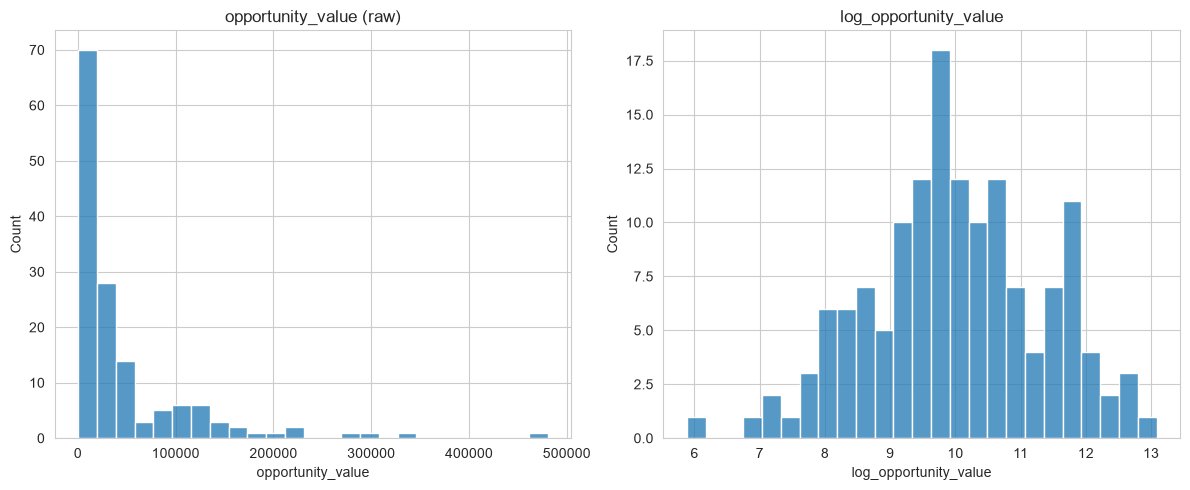

Modeling on the log-transformed target -- this is standard for right-skewed monetary
targets and keeps a handful of very large deals from dominating the loss function.
Predictions are exponentiated back with expm1() when reporting $ metrics below.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(model_df["opportunity_value"], bins=25, ax=axes[0])
axes[0].set_title("opportunity_value (raw)")
sns.histplot(model_df["log_opportunity_value"], bins=25, ax=axes[1])
axes[1].set_title("log_opportunity_value")
plt.tight_layout()
plt.show()

print("Modeling on the log-transformed target -- this is standard for right-skewed monetary")
print("targets and keeps a handful of very large deals from dominating the loss function.")
print("Predictions are exponentiated back with expm1() when reporting $ metrics below.")

## Build feature matrix

Categorical predictors: `segment`, `opp_owner_geo`, `opportunity_type`, `dominant_product_line`.
Numeric predictors: `product_family_count`, `is_multi_product_line`.

We one-hot encode categoricals and let `PolynomialFeatures`-style interaction terms come from
explicit interaction columns (Product x Geography, Product x Segment) rather than a blanket
interaction expansion, since with 145 rows we want to keep the design matrix small and interpretable.

In [5]:
categorical_cols = ["segment", "opp_owner_geo", "opportunity_type", "dominant_product_line"]
numeric_cols = ["product_family_count", "is_multi_product_line"]

# Explicit interaction terms: Product x Geography, Product x Segment
model_df["product_x_geo"] = model_df["dominant_product_line"] + " | " + model_df["opp_owner_geo"]
model_df["product_x_segment"] = model_df["dominant_product_line"] + " | " + model_df["segment"]

interaction_cols = ["product_x_geo", "product_x_segment"]

feature_cols = categorical_cols + interaction_cols + numeric_cols
X = model_df[feature_cols].copy()
y = model_df["log_opportunity_value"].copy()

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (145, 8)


,segment,opp_owner_geo,opportunity_type,dominant_product_line,product_x_geo,product_x_segment,product_family_count,is_multi_product_line
0,Enterprise,AMER,New Business,Workforce,Workforce | AMER,Workforce | Enterprise,3,0
1,Enterprise,AMER,Upsell,Workforce,Workforce | AMER,Workforce | Enterprise,3,0
2,Corporate,AMER,New Business,Workforce,Workforce | AMER,Workforce | Corporate,4,0
3,Corporate,AMER,Upsell,Workforce,Workforce | AMER,Workforce | Corporate,1,0
4,Enterprise,AMER,Upsell,Workforce,Workforce | AMER,Workforce | Enterprise,3,0


## Train / test split

With only 145 rows, an 80/20 split still leaves a workable test set (~29 rows). We also use 5-fold cross-validation on the training set for more stable model comparison given the small sample.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

cat_all_cols = categorical_cols + interaction_cols
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_all_cols),
        ("num", StandardScaler(), numeric_cols),
    ]
)

Train: 116 rows, Test: 29 rows


## Part 1 — Interpretable models: Linear, Ridge, Lasso

Fit all three, compare via 5-fold CV on the training set, then evaluate the best on the held-out test set.

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    cv_results.append({"Model": name, "CV RMSE (log scale)": -scores.mean(), "CV RMSE std": scores.std()})

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,CV RMSE (log scale),CV RMSE std
0,Linear Regression,1.09,0.12
1,Ridge (alpha=1.0),1.09,0.11
2,Lasso (alpha=0.01),1.09,0.11


In [8]:
def evaluate_on_test(pipe, name):
    pipe.fit(X_train, y_train)
    preds_log = pipe.predict(X_test)

    # Metrics on log scale
    mae_log = mean_absolute_error(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    r2_log = r2_score(y_test, preds_log)

    # Metrics back on $ scale (expm1 to undo log1p)
    y_test_dollars = np.expm1(y_test)
    preds_dollars = np.expm1(preds_log)
    mae_dollars = mean_absolute_error(y_test_dollars, preds_dollars)
    rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, preds_dollars))
    r2_dollars = r2_score(y_test_dollars, preds_dollars)

    return {
        "Model": name,
        "Test R2 (log)": r2_log, "Test MAE (log)": mae_log, "Test RMSE (log)": rmse_log,
        "Test R2 ($)": r2_dollars, "Test MAE ($)": mae_dollars, "Test RMSE ($)": rmse_dollars,
    }, pipe

results = []
fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    res, fitted = evaluate_on_test(pipe, name)
    results.append(res)
    fitted_pipes[name] = fitted

linear_results_df = pd.DataFrame(results)
linear_results_df

,Model,Test R2 (log),Test MAE (log),Test RMSE (log),Test R2 ($),Test MAE ($),Test RMSE ($)
0,Linear Regression,0.30,0.94,1.27,0.18,"28,446.98","59,992.19"
1,Ridge (alpha=1.0),0.30,0.94,1.27,0.18,"28,769.35","60,099.03"
2,Lasso (alpha=0.01),0.30,0.94,1.28,0.17,"28,461.89","60,307.39"


### Interpreting Linear Regression coefficients

Coefficients are on the log-target scale, so `exp(coef) - 1` approximates the % change in opportunity value associated with that category (holding others constant, one-hot encoding baseline caveats aside).

In [9]:
lr_pipe = fitted_pipes["Linear Regression"]
feature_names = lr_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = lr_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef_log_scale": coefs})
coef_df["approx_pct_effect"] = (np.exp(coef_df["coef_log_scale"]) - 1) * 100
coef_df = coef_df.sort_values("coef_log_scale", ascending=False)
coef_df

,feature,coef_log_scale,approx_pct_effect
1,cat__segment_Enterprise,0.49,62.83
15,cat__product_x_segment_CIAM | Enterprise,0.45,57.57
18,num__product_family_count,0.28,32.86
7,cat__dominant_product_line_CIAM,0.26,30.15
10,cat__product_x_geo_CIAM | EMEA,0.26,29.36
5,cat__opportunity_type_New Business,0.24,27.13
4,cat__opp_owner_geo_EMEA,0.15,15.78
19,num__is_multi_product_line,0.03,3.42
17,cat__product_x_segment_Workforce | Enterprise,0.03,3.33
9,cat__product_x_geo_CIAM | AMER,0.01,0.61


/var/folders/f_/1mm1mz0x0rdg1ysp2gw5927r0000gn/T/ipykernel_46936/3284402193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coefs, x="coef_log_scale", y="feature", palette="coolwarm")


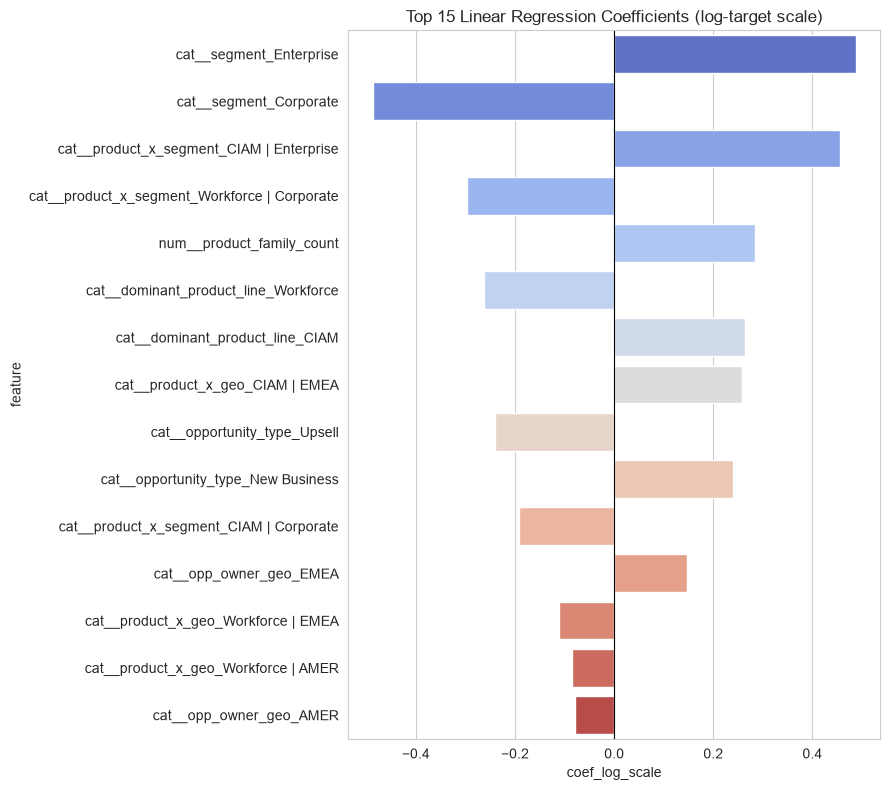

In [10]:
plt.figure(figsize=(9, 8))
top_coefs = coef_df.reindex(coef_df["coef_log_scale"].abs().sort_values(ascending=False).index).head(15)
sns.barplot(data=top_coefs, x="coef_log_scale", y="feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Linear Regression Coefficients (log-target scale)")
plt.tight_layout()
plt.show()

**Reading the interaction terms:** look specifically at the `product_x_geo` and
`product_x_segment` rows above. If, say, `Workforce | Enterprise` has a much larger positive
coefficient than `Workforce` alone would suggest from segment and product main effects combined,
that's evidence of a genuine interaction — Workforce isn't just valuable, it's specifically
valuable *when sold to Enterprise*. Fill in your actual reading here once you've run it.

## Part 2 — Nonlinear models: Random Forest and XGBoost

In [11]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE)),
])
rf_res, rf_pipe = evaluate_on_test(rf_pipe, "Random Forest")

nonlinear_results = [rf_res]

if HAS_XGB:
    xgb_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", xgb.XGBRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE
        )),
    ])
    xgb_res, xgb_pipe = evaluate_on_test(xgb_pipe, "XGBoost")
    nonlinear_results.append(xgb_res)

nonlinear_results_df = pd.DataFrame(nonlinear_results)
nonlinear_results_df

,Model,Test R2 (log),Test MAE (log),Test RMSE (log),Test R2 ($),Test MAE ($),Test RMSE ($)
0,Random Forest,0.25,0.98,1.32,0.19,"28,700.16","59,502.44"


## Full model comparison

With only 145 rows and ~15-20 one-hot features, tree ensembles are prone to overfitting -- watch for nonlinear models showing much better train performance but similar or worse test performance than the linear models. If so, that's a legitimate finding (favor the interpretable model), not a failure of the notebook.

In [12]:
all_results_df = pd.concat([linear_results_df, nonlinear_results_df], ignore_index=True)
all_results_df = all_results_df[["Model", "Test R2 ($)", "Test MAE ($)", "Test RMSE ($)", "Test R2 (log)", "Test MAE (log)", "Test RMSE (log)"]]
all_results_df.sort_values("Test R2 ($)", ascending=False)

,Model,Test R2 ($),Test MAE ($),Test RMSE ($),Test R2 (log),Test MAE (log),Test RMSE (log)
3,Random Forest,0.19,"28,700.16","59,502.44",0.25,0.98,1.32
0,Linear Regression,0.18,"28,446.98","59,992.19",0.30,0.94,1.27
1,Ridge (alpha=1.0),0.18,"28,769.35","60,099.03",0.30,0.94,1.27
2,Lasso (alpha=0.01),0.17,"28,461.89","60,307.39",0.30,0.94,1.28


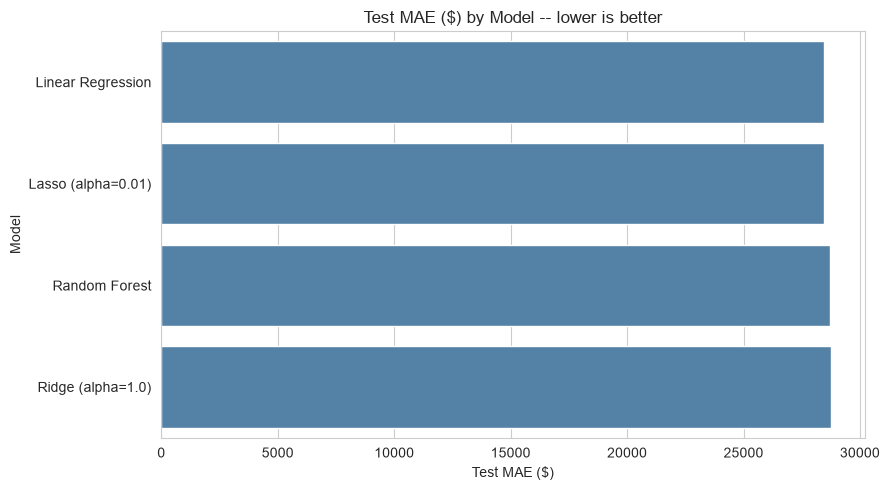

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(data=all_results_df.sort_values("Test MAE ($)"), x="Test MAE ($)", y="Model", color="steelblue")
plt.title("Test MAE ($) by Model -- lower is better")
plt.tight_layout()
plt.show()

## Feature importance (Random Forest)

Tree-based feature importance as a cross-check against the linear coefficients above. Note this
reflects predictive contribution, not necessarily causal effect -- read alongside the statistical
tests in `03_statistical_analysis.ipynb`, not as a replacement for them.

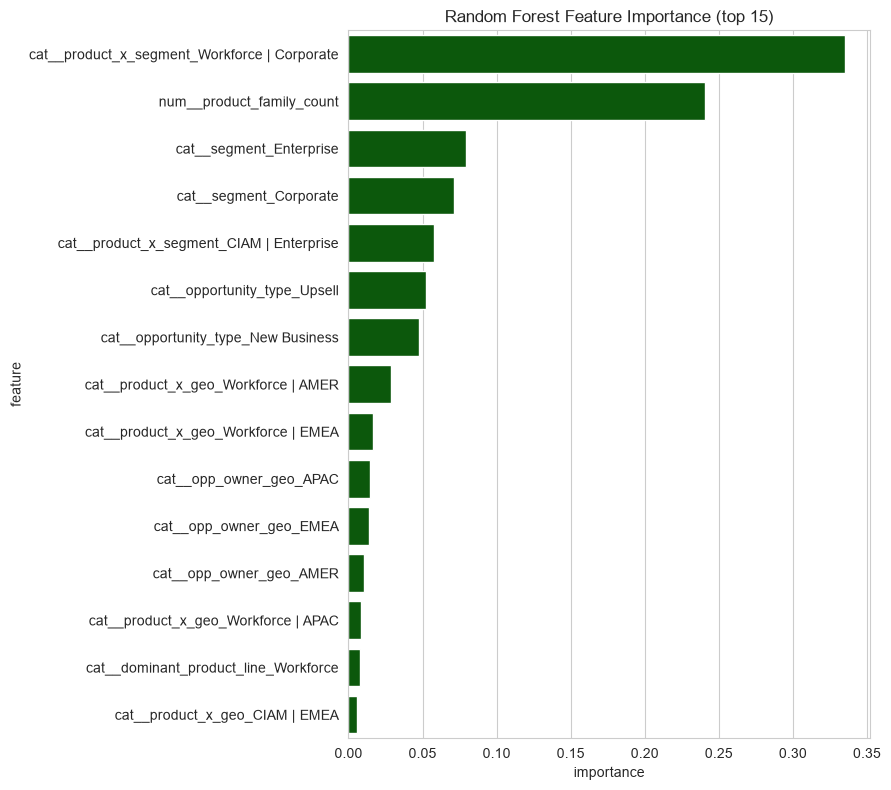

,feature,importance
16,cat__product_x_segment_Workforce | Corporate,0.34
18,num__product_family_count,0.24
1,cat__segment_Enterprise,0.08
0,cat__segment_Corporate,0.07
15,cat__product_x_segment_CIAM | Enterprise,0.06
6,cat__opportunity_type_Upsell,0.05
5,cat__opportunity_type_New Business,0.05
11,cat__product_x_geo_Workforce | AMER,0.03
13,cat__product_x_geo_Workforce | EMEA,0.02
3,cat__opp_owner_geo_APAC,0.01


In [14]:
rf_model = rf_pipe.named_steps["model"]
rf_feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", color="darkgreen")
plt.title("Random Forest Feature Importance (top 15)")
plt.tight_layout()
plt.show()

importance_df.head(15)

### Optional: SHAP values

Uncomment and run if you have `shap` installed (`pip install shap`). With n=145 this is more
for interpretability practice than a strict necessity -- feature importance above already gives
the headline story, but SHAP gives per-prediction, signed, interaction-aware explanations.

In [15]:
# import shap
#
# explainer = shap.TreeExplainer(rf_model)
# X_test_transformed = rf_pipe.named_steps["preprocess"].transform(X_test)
# shap_values = explainer.shap_values(X_test_transformed)
#
# shap.summary_plot(shap_values, X_test_transformed, feature_names=rf_feature_names)

## Residual diagnostics (best interpretable model)

Checks whether the linear model's errors look reasonably random (good) or show clear patterns by
segment/geography (a sign the model is systematically missing something for that group).

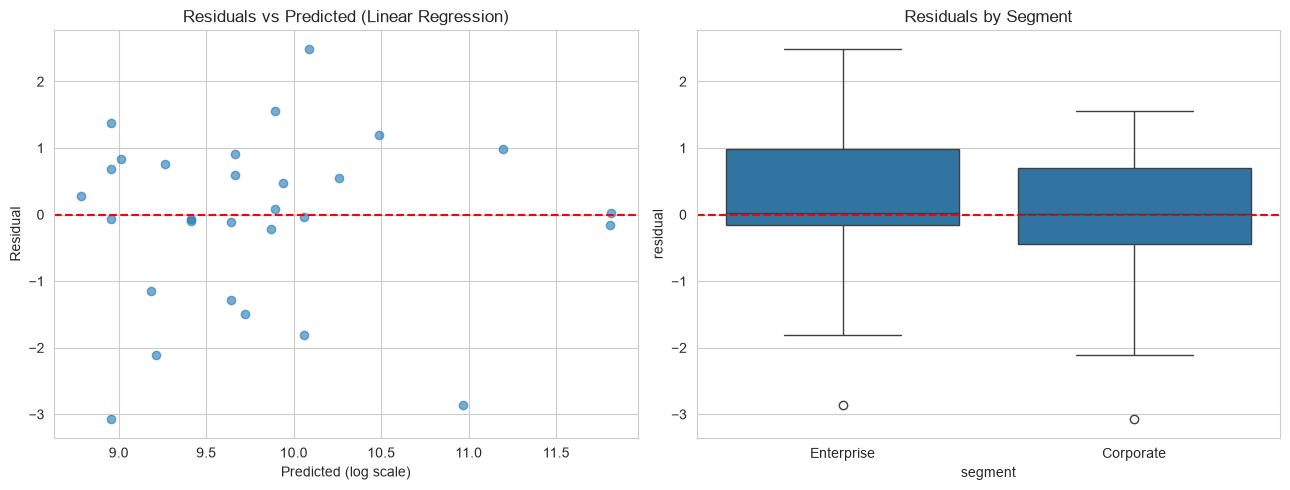

In [16]:
best_linear_name = linear_results_df.sort_values("Test R2 ($)", ascending=False).iloc[0]["Model"]
best_pipe = fitted_pipes[best_linear_name]

preds_log = best_pipe.predict(X_test)
residuals = y_test.values - preds_log

resid_df = X_test.copy()
resid_df["residual"] = residuals
resid_df["predicted_log"] = preds_log
resid_df["actual_log"] = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(resid_df["predicted_log"], resid_df["residual"], alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted (log scale)")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residuals vs Predicted ({best_linear_name})")

sns.boxplot(data=resid_df, x="segment", y="residual", ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals by Segment")
plt.tight_layout()
plt.show()

## Summary

Best model is essentially a toss-up between plain Linear Regression and Random Forest (R² on $ scale: RF 0.19, Linear 0.18) — added complexity bought basically nothing on 145 rows, matching the notebook's own caveat. CV RMSE was flat across Linear/Ridge/Lasso (~1.09), so regularization didn't help either — no overfitting problem, just a hard prediction problem (R²≈0.18-0.30 means most variance is unexplained by these categorical features alone).
Top linear coefficients: segment_Enterprise (+0.49 log-scale) is the single strongest driver, followed by product_x_segment: CIAM|Enterprise (+0.45) — confirming the 03 interaction finding: CIAM's apparent premium is largely a segment effect, not a pure product effect. product_family_count also mattered (+0.28). RF's feature importance agrees directionally: product_x_segment: Workforce|Corporate and product_family_count were its top two features.